In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cdist
from sklearn.utils import check_random_state

# TopOMetry pipeline
from topo.base.ann import kNN
from topo.tpgraph.kernels import Kernel
from topo.spectral.eigen import EigenDecomposition, spectral_layout
from topo.layouts.projector import Projector
from topo.topograph import _KERNEL_CONFIGS

# Evaluation metrics
from topo.eval.global_scores import global_score_pca, global_score_laplacian
from topo.eval.local_scores import geodesic_correlation
from topo.eval.rmetric import (
    RiemannMetric,
    calculate_deformation,
    plot_riemann_metric_localized,
    plot_metric_contraction_expansion,
)
from topo.eval.topo_metrics import (
    get_P,
    topo_preserve_score,
    rank_diffusion_correlation,
    spectral_procrustes,
    rowwise_js_similarity,
    sparse_neighborhood_f1,
    spectral_similarity,
)

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# TUNABLE CONSTANTS — edit this cell and re-run all cells below
# ══════════════════════════════════════════════════════════════════════════════

# ── Data source ──────────────────────────────────────────────────────────────
# Set USE_CUSTOM_DATA = True and fill DATA_PATH / COLOR_PATH to load your own.
USE_CUSTOM_DATA = False
DATA_PATH  = Path("../data/my_data.npy")  # (n_samples, n_features) array
COLOR_PATH = None                          # optional: Path("...") for (n_samples,) color array
SCALE_DATA = False  # recommended for Euclidean/cKNN when features have different units

# Swiss-roll settings (ignored when USE_CUSTOM_DATA = True)
N_SAMPLES = 2000
NOISE = 0.5
RANDOM_STATE = 42

# ── kNN graph ────────────────────────────────────────────────────────────────
N_NEIGHBORS = 15
METRIC = "euclidean"  # any metric accepted by the backend
BACKEND = "hnswlib"  # "hnswlib" | "nmslib" | "sklearn"

# ── Kernel version ───────────────────────────────────────────────────────────
# Choose one of:
#   "bw_adaptive"                              — adaptive-bandwidth Gaussian (default)
#   "bw_adaptive_alpha_decaying"               — + alpha-decaying exponent
#   "bw_adaptive_nbr_expansion"                — + expanded neighbor search
#   "bw_adaptive_alpha_decaying_nbr_expansion" — both alpha-decaying + expansion
#   "fuzzy"                                    — UMAP-style fuzzy simplicial sets
#   "cknn"                                     — continuous k-nearest-neighbors
#   "gaussian"                                 — fixed-bandwidth Gaussian (set SIGMA)
KERNEL_VERSION = "cknn"
SIGMA = 1.0  # bandwidth for "gaussian" kernel version
ANISOTROPY = 1.0  # alpha for diffusion operator (0–1)

# ── Eigendecomposition / scaffold ────────────────────────────────────────────
N_COMPONENTS_DM = 64  # eigenvectors to compute
DM_METHOD = "msDM"  # "DM" | "msDM" | "LE"
EIGENSOLVER = "arpack"  # "arpack" | "lobpcg" | "amg"
DIFFUSION_TIME = 0  # t=0 → multiscale; t>0 → fixed-time DM

# ── 2-D layout ───────────────────────────────────────────────────────────────
PROJECTION_METHOD = "PaCMAP"  # "MAP" | "UMAP" | "PaCMAP" | "Isomap" | "t-SNE"
N_COMPONENTS_2D = 2
NUM_ITERS = 500  # optimization iterations (MAP / UMAP)

# ── Output ───────────────────────────────────────────────────────────────────
SAVE_FIGURES = False               # set True to save all plots to disk
OUTPUT_DIR   = Path("../figures")  # directory (created automatically when saving)

In [3]:
# ── Load or generate data ─────────────────────────────────────────────────────
if USE_CUSTOM_DATA:
    X = np.load(DATA_PATH)
    color = np.load(COLOR_PATH) if COLOR_PATH is not None else np.arange(X.shape[0])
    print(f"Loaded custom data: {X.shape}")
else:
    from sklearn.datasets import make_swiss_roll

    X, color = make_swiss_roll(
        n_samples=N_SAMPLES, noise=NOISE, random_state=RANDOM_STATE
    )
    print(f"Generated Swiss Roll: {X.shape}")

if SCALE_DATA:
    from sklearn.preprocessing import StandardScaler

    X = StandardScaler().fit_transform(X)
    print("Applied StandardScaler to X")

Generated Swiss Roll: (2000, 3)


In [4]:
# ── Step 1: kNN graph in input space ──────────────────────────────────────────
knn_X = kNN(X, n_neighbors=N_NEIGHBORS, metric=METRIC, backend=BACKEND)

# ── Step 2: kernel on input space ─────────────────────────────────────────────
# Build Kernel kwargs from the chosen KERNEL_VERSION
kernel_cfg = _KERNEL_CONFIGS[KERNEL_VERSION].copy()
if KERNEL_VERSION == "gaussian":
    kernel_cfg["sigma"] = SIGMA

kernel_X = Kernel(
    n_neighbors=N_NEIGHBORS,
    metric=METRIC,
    backend=BACKEND,
    anisotropy=ANISOTROPY,
    **kernel_cfg,
)
kernel_X.fit(X)
P_X = kernel_X.P  # diffusion operator
L_X = kernel_X.L  # graph Laplacian

print(f"Kernel version : {KERNEL_VERSION}")
print(f"K shape        : {kernel_X.K.shape},  nnz = {kernel_X.K.nnz}")

# ── Step 3: eigendecomposition → scaffold ─────────────────────────────────────
eigen = EigenDecomposition(
    n_components=N_COMPONENTS_DM,
    method=DM_METHOD,
    eigensolver=EIGENSOLVER,
    drop_first=True,
    weight=True,
    t=DIFFUSION_TIME,
)
eigen.fit(kernel_X)
Z = eigen.transform(X)  # (n, n_eigs) scaffold coordinates

print(f"Scaffold method: {DM_METHOD},  shape = {Z.shape}")

Kernel version : cknn
K shape        : (2000, 2000),  nnz = 34098
Scaffold method: msDM,  shape = (2000, 64)


In [5]:
# ── Step 4: kNN in scaffold space ─────────────────────────────────────────────
knn_Z = kNN(Z, n_neighbors=N_NEIGHBORS, metric=METRIC, backend=BACKEND)

# ── Step 5: refined kernel on scaffold ────────────────────────────────────────
kernel_Z = Kernel(
    n_neighbors=N_NEIGHBORS,
    metric=METRIC,
    backend=BACKEND,
    anisotropy=ANISOTROPY,
    **kernel_cfg,  # same kernel version as the base graph
)
kernel_Z.fit(Z)

# ── Step 6: spectral initialisation for layout ───────────────────────────────
init_Y = spectral_layout(
    graph=kernel_Z.K, dim=N_COMPONENTS_2D, random_state=RANDOM_STATE
)

# ── Step 7: 2-D layout ───────────────────────────────────────────────────────
proj = Projector(
    projection_method=PROJECTION_METHOD,
    n_components=N_COMPONENTS_2D,
    n_neighbors=N_NEIGHBORS,
    num_iters=NUM_ITERS,
    init="spectral",
)
# MAP consumes the kernel matrix; other methods take scaffold coordinates
if PROJECTION_METHOD == "MAP":
    proj.fit(kernel_Z.K)
else:
    proj.fit(Z)
Y = proj.Y_

print(f"Layout method  : {PROJECTION_METHOD},  shape = {Y.shape}")

Layout method  : PaCMAP,  shape = (2000, 2)


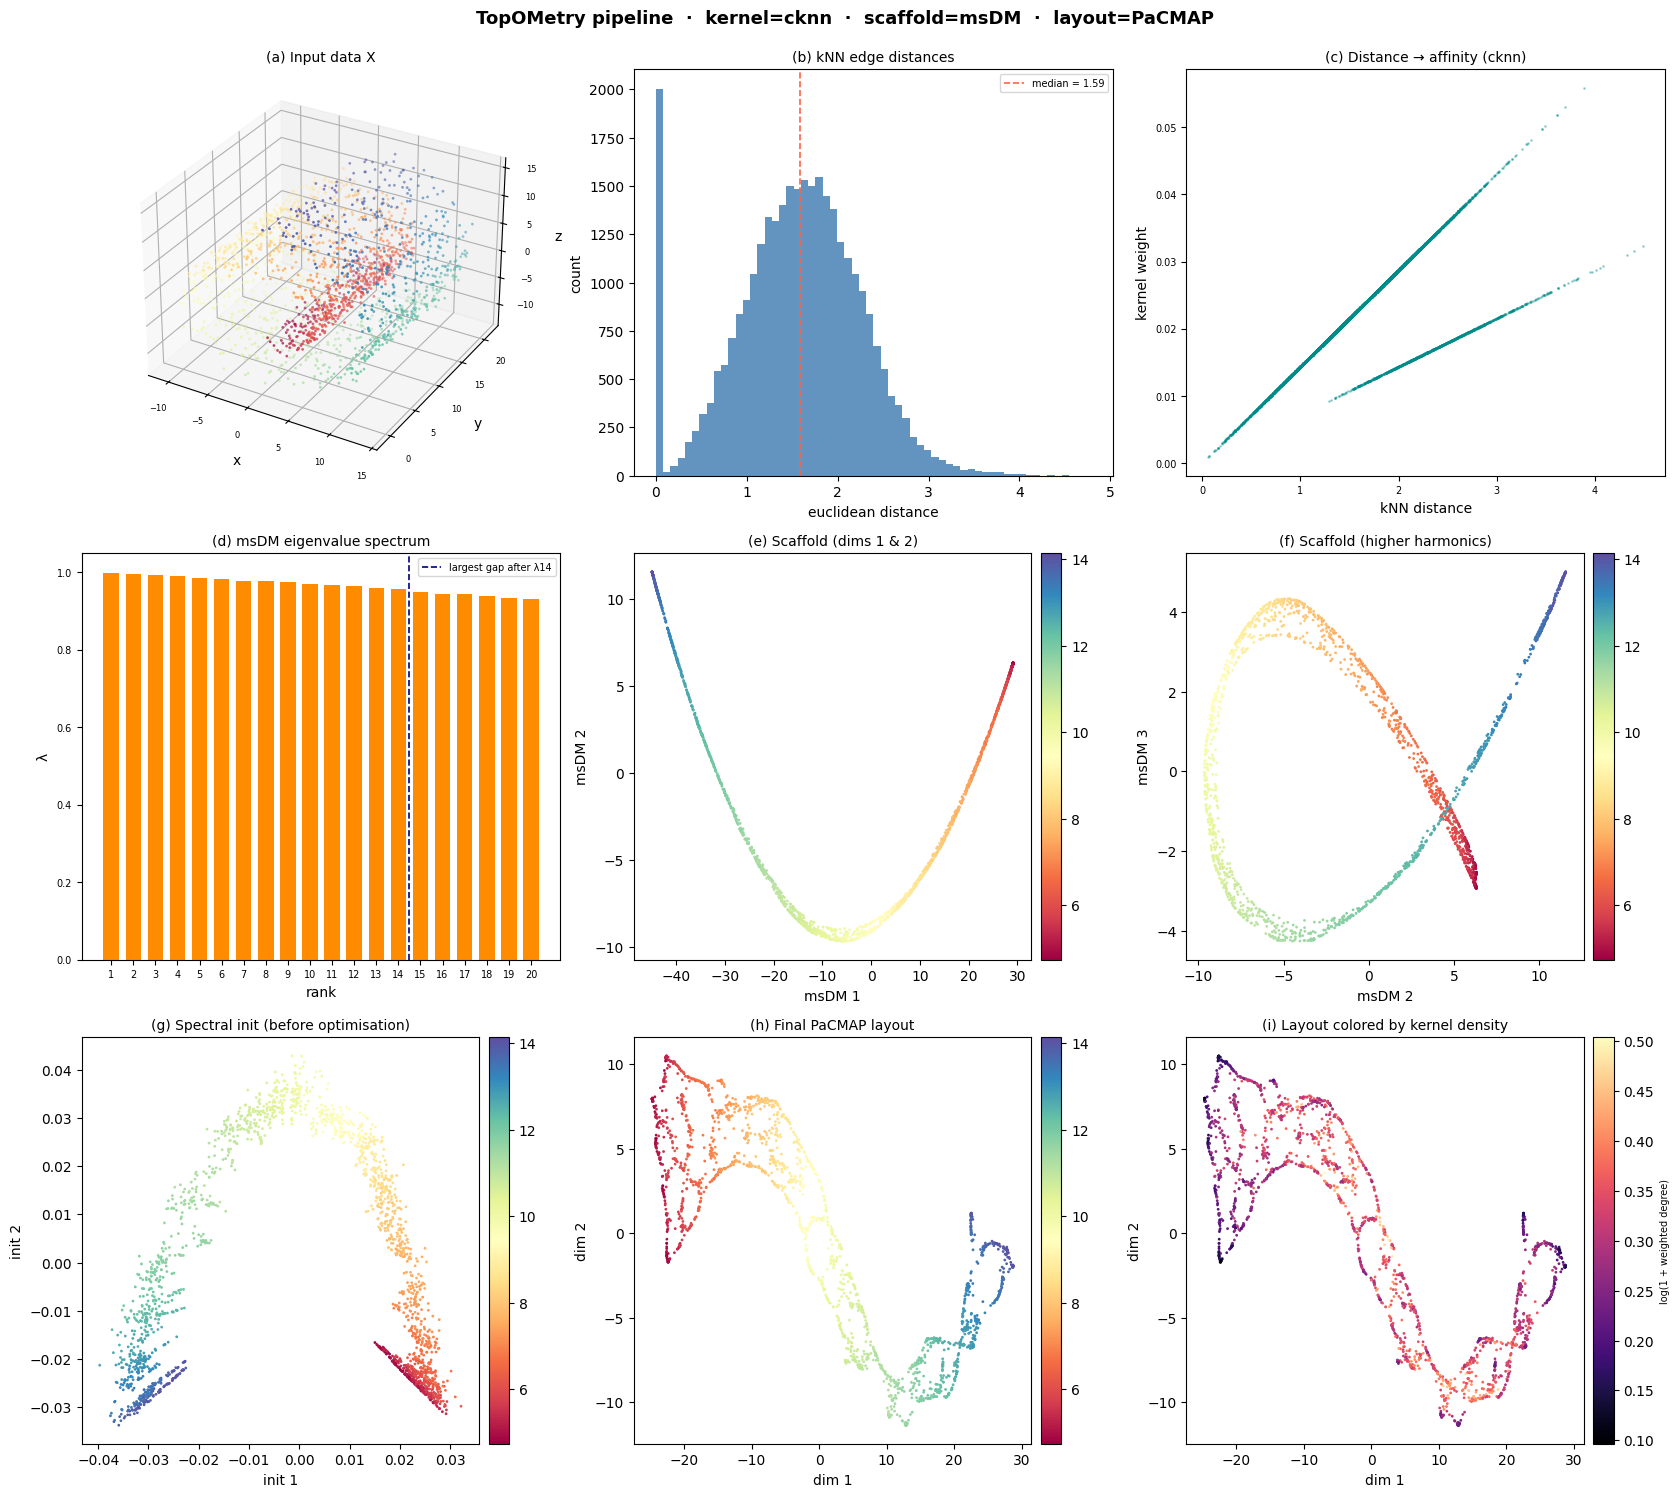

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Visualization — 3×3 panel overview of the full pipeline
# ══════════════════════════════════════════════════════════════════════════════

n_dim = X.shape[1]
use_3d = n_dim >= 3 and not USE_CUSTOM_DATA

fig = plt.figure(figsize=(17, 15))
title = (
    f"TopOMetry pipeline  ·  kernel={KERNEL_VERSION}  ·  scaffold={DM_METHOD}  "
    f"·  layout={PROJECTION_METHOD}"
)
fig.suptitle(title, fontsize=13, fontweight="bold", y=0.995)

# ═══════════════════════════════════════════════════════════════════════════
# Row 1 — Input space: data → graph → kernel
# ═══════════════════════════════════════════════════════════════════════════

# ── 1  Input data ────────────────────────────────────────────────────────
if use_3d:
    ax1 = fig.add_subplot(3, 3, 1, projection="3d")
    ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap="Spectral", s=4, linewidths=0)
    ax1.set_title("(a) Input data X", fontsize=10)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")
    ax1.tick_params(labelsize=6)
else:
    ax1 = fig.add_subplot(3, 3, 1)
    sc1 = ax1.scatter(X[:, 0], X[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
    ax1.set_title("(a) Input data X (dims 1 & 2)", fontsize=10)
    ax1.set_xlabel("dim 1")
    ax1.set_ylabel("dim 2")
    plt.colorbar(sc1, ax=ax1, pad=0.02)

# ── 2  kNN edge-distance distribution ───────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
edge_dists = knn_X.data
ax2.hist(edge_dists, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
med = np.median(edge_dists)
ax2.axvline(med, color="tomato", lw=1.2, ls="--", label=f"median = {med:.2f}")
ax2.set_title("(b) kNN edge distances", fontsize=10)
ax2.set_xlabel(f"{METRIC} distance")
ax2.set_ylabel("count")
ax2.legend(fontsize=7)

# ── 3  Distance → kernel affinity ───────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
K_csr = kernel_X.K.tocsr()
knn_csr = knn_X.tocsr()
rows, cols = K_csr.nonzero()
if len(rows) > 10_000:
    rng = np.random.default_rng(RANDOM_STATE)
    sel = rng.choice(len(rows), 10_000, replace=False)
    rows, cols = rows[sel], cols[sel]
d_vals = np.asarray(knn_csr[rows, cols]).ravel()
k_vals = np.asarray(K_csr[rows, cols]).ravel()
mask = d_vals > 0
ax3.scatter(
    d_vals[mask], k_vals[mask], s=1, alpha=0.3, color="darkcyan", rasterized=True
)
ax3.set_title(f"(c) Distance → affinity ({KERNEL_VERSION})", fontsize=10)
ax3.set_xlabel("kNN distance")
ax3.set_ylabel("kernel weight")
ax3.tick_params(labelsize=7)

# ═══════════════════════════════════════════════════════════════════════════
# Row 2 — Spectral scaffold
# ═══════════════════════════════════════════════════════════════════════════

# ── 4  Eigenvalue spectrum ──────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
evals = eigen.eigenvalues
n_show = min(20, len(evals))
idx = np.arange(1, n_show + 1)
ax4.bar(idx, evals[:n_show], color="darkorange", width=0.7)
gaps = np.abs(np.diff(evals[:n_show]))
gap_idx = np.argmax(gaps)
ax4.axvline(
    gap_idx + 1.5,
    color="navy",
    lw=1.2,
    ls="--",
    label=f"largest gap after λ{gap_idx + 1}",
)
ax4.set_title(f"(d) {DM_METHOD} eigenvalue spectrum", fontsize=10)
ax4.set_xlabel("rank")
ax4.set_ylabel("λ")
ax4.set_xticks(idx)
ax4.tick_params(labelsize=7)
ax4.legend(fontsize=7)

# ── 5  Scaffold dims 1 & 2 ──────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
sc5 = ax5.scatter(Z[:, 0], Z[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
ax5.set_title("(e) Scaffold (dims 1 & 2)", fontsize=10)
ax5.set_xlabel(f"{DM_METHOD} 1")
ax5.set_ylabel(f"{DM_METHOD} 2")
plt.colorbar(sc5, ax=ax5, pad=0.02)

# ── 6  Scaffold dims 2 & 3 (higher harmonics) ──────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
if Z.shape[1] >= 3:
    sc6 = ax6.scatter(Z[:, 1], Z[:, 2], c=color, cmap="Spectral", s=4, linewidths=0)
    ax6.set_xlabel(f"{DM_METHOD} 2")
    ax6.set_ylabel(f"{DM_METHOD} 3")
else:
    sc6 = ax6.scatter(Z[:, 0], Z[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
    ax6.set_xlabel(f"{DM_METHOD} 1")
    ax6.set_ylabel(f"{DM_METHOD} 2")
ax6.set_title("(f) Scaffold (higher harmonics)", fontsize=10)
plt.colorbar(sc6, ax=ax6, pad=0.02)

# ═══════════════════════════════════════════════════════════════════════════
# Row 3 — Layout
# ═══════════════════════════════════════════════════════════════════════════

# ── 7  Spectral initialisation ──────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
sc7 = ax7.scatter(
    init_Y[:, 0], init_Y[:, 1], c=color, cmap="Spectral", s=4, linewidths=0
)
ax7.set_title("(g) Spectral init (before optimisation)", fontsize=10)
ax7.set_xlabel("init 1")
ax7.set_ylabel("init 2")
plt.colorbar(sc7, ax=ax7, pad=0.02)

# ── 8  Final 2-D layout ────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
sc8 = ax8.scatter(Y[:, 0], Y[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
ax8.set_title(f"(h) Final {PROJECTION_METHOD} layout", fontsize=10)
ax8.set_xlabel("dim 1")
ax8.set_ylabel("dim 2")
plt.colorbar(sc8, ax=ax8, pad=0.02)

# ── 9  Local density on layout ──────────────────────────────────────────
# Weighted degree = row sums of the kernel matrix (∝ local density)
ax9 = fig.add_subplot(3, 3, 9)
log_degree = np.log1p(np.asarray(kernel_Z.K.sum(axis=1)).ravel())
sc9 = ax9.scatter(Y[:, 0], Y[:, 1], c=log_degree, cmap="magma", s=4, linewidths=0)
ax9.set_title("(i) Layout colored by kernel density", fontsize=10)
ax9.set_xlabel("dim 1")
ax9.set_ylabel("dim 2")
cb = plt.colorbar(sc9, ax=ax9, pad=0.02)
cb.set_label("log(1 + weighted degree)", fontsize=7)

plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"pipeline_{KERNEL_VERSION}_{DM_METHOD}_{PROJECTION_METHOD}.png",
                dpi=150, bbox_inches="tight")
    print(f"Saved → {OUTPUT_DIR}/pipeline_{KERNEL_VERSION}_{DM_METHOD}_{PROJECTION_METHOD}.png")
plt.show()

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Quick reference — all available options
# ══════════════════════════════════════════════════════════════════════════════
print("""
┌─────────────────────────────────────────────────────────────────────┐
│  KERNEL_VERSION options:                                            │
│    "bw_adaptive"                 — adaptive-bandwidth Gaussian      │
│    "bw_adaptive_alpha_decaying"  — + alpha-decaying exponent        │
│    "bw_adaptive_nbr_expansion"   — + expanded neighbor search       │
│    "bw_adaptive_alpha_decaying_nbr_expansion" — both combined       │
│    "fuzzy"                       — UMAP-style fuzzy simplicial sets │
│    "cknn"                        — continuous k-nearest-neighbors   │
│    "gaussian"                    — fixed-bandwidth (set SIGMA)      │
├─────────────────────────────────────────────────────────────────────┤
│  DM_METHOD options:                                                 │
│    "DM"    — diffusion maps                                         │
│    "msDM"  — multiscale diffusion maps                              │
│    "LE"    — Laplacian eigenmaps                                    │
├─────────────────────────────────────────────────────────────────────┤
│  PROJECTION_METHOD options:                                         │
│    "MAP"     — Manifold Approximation and Projection (native)       │
│    "UMAP"    — Uniform Manifold Approximation (pip install umap)    │
│    "PaCMAP"  — Pairwise Controlled Manifold Approx.                 │
│    "Isomap"  — Isometric Mapping                                    │
│    "t-SNE"   — t-distributed Stochastic Neighbor Embedding          │
│    "TriMAP"  — TriMap (pip install trimap)                           │
│    "NCVis"   — NCVis (pip install ncvis)                             │
│    "IsomorphicMDE" — MDE isomorphic (pip install pymde)             │
│    "IsometricMDE"  — MDE isometric (pip install pymde)              │
├─────────────────────────────────────────────────────────────────────┤
│  METRIC options (depends on backend):                               │
│    "euclidean", "cosine", "l1", "angular", "hamming", ...           │
├─────────────────────────────────────────────────────────────────────┤
│  BACKEND options:                                                   │
│    "hnswlib" (default, fast)  |  "nmslib"  |  "sklearn" (exact)     │
└─────────────────────────────────────────────────────────────────────┘

To load your own data, set USE_CUSTOM_DATA = True in cell 2 and point
DATA_PATH to a .npy file of shape (n_samples, n_features).
Optionally set COLOR_PATH to a .npy file of shape (n_samples,).
""")


┌─────────────────────────────────────────────────────────────────────┐
│  KERNEL_VERSION options:                                            │
│    "bw_adaptive"                 — adaptive-bandwidth Gaussian      │
│    "bw_adaptive_alpha_decaying"  — + alpha-decaying exponent        │
│    "bw_adaptive_nbr_expansion"   — + expanded neighbor search       │
│    "bw_adaptive_alpha_decaying_nbr_expansion" — both combined       │
│    "fuzzy"                       — UMAP-style fuzzy simplicial sets │
│    "cknn"                        — continuous k-nearest-neighbors   │
│    "gaussian"                    — fixed-bandwidth (set SIGMA)      │
├─────────────────────────────────────────────────────────────────────┤
│  DM_METHOD options:                                                 │
│    "DM"    — diffusion maps                                         │
│    "msDM"  — multiscale diffusion maps                              │
│    "LE"    — Laplacian eigenmaps                             

── Global scores (higher = better, max 1.0) ──
  vs PCA baseline       : 0.2722
  vs Laplacian baseline : 1.0000

── Geodesic correlation (Spearman, 500 landmarks) ──
  rho = 0.2540

── TopoPreserve composite score ──
  Composite             : 0.6376
  Neighborhood F1 (PF1) : 0.6718   (set overlap)
  JS similarity  (PJS)  : 0.5857   (weight-sensitive)
  Spectral Procrustes   : 0.6552   (global geometry)

── Additional diffusion metrics ──
  Rank diffusion corr.  : 0.4475    (Spearman, range [-1, 1])
  Spectral similarity   : 0.9991    (eigenspace alignment)

── Riemannian deformation (centered log det G) ──
  mean  = +11.2550   std = 13.1533
  range = [0.000, 36.563]


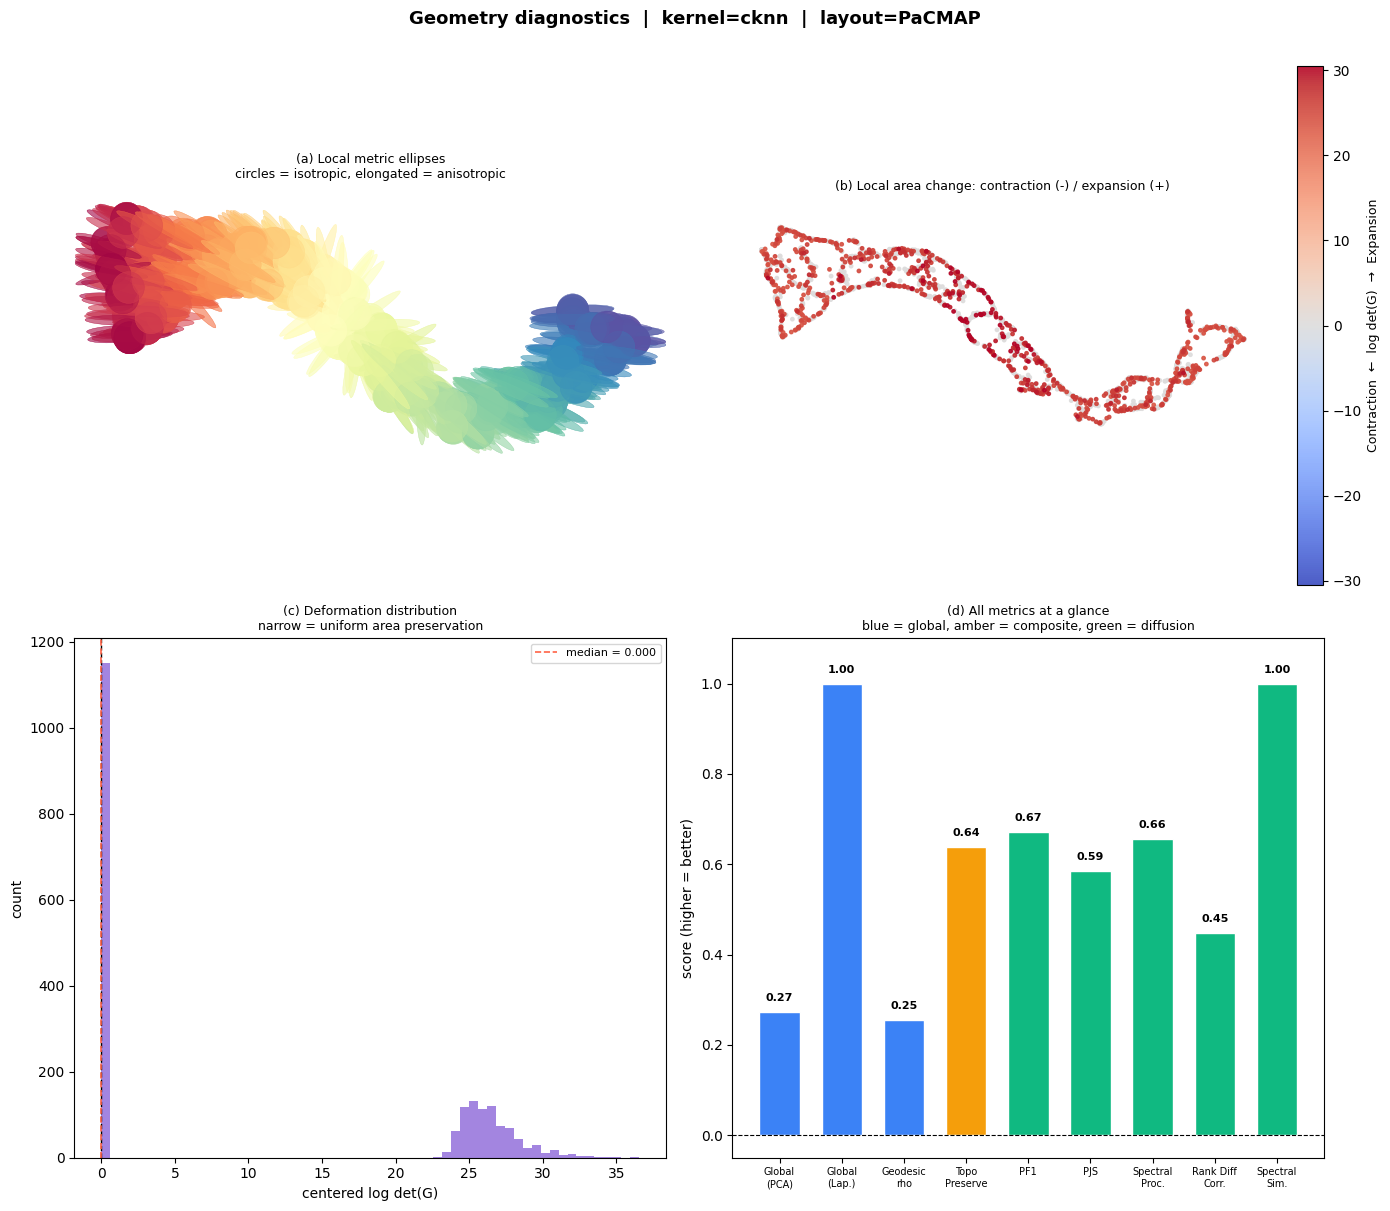

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Evaluation — compute all geometry-preservation metrics + summary plots
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Global structure preservation (vs PCA / Laplacian baselines) ──────────
gs_pca = global_score_pca(X, Y)
gs_lap = global_score_laplacian(X, Y, k=N_NEIGHBORS, random_state=RANDOM_STATE)
print("── Global scores (higher = better, max 1.0) ──")
print(f"  vs PCA baseline       : {gs_pca:.4f}")
print(f"  vs Laplacian baseline : {gs_lap:.4f}")

# ── 2. Geodesic correlation (rank correlation of shortest-path distances) ────
geo_r = geodesic_correlation(
    X, Y,
    n_neighbors=N_NEIGHBORS,
    metric=METRIC,
    cor_method="spearman",
    landmarks=min(500, X.shape[0]),
    random_state=RANDOM_STATE,
)
print(f"\n── Geodesic correlation (Spearman, {min(500, X.shape[0])} landmarks) ──")
print(f"  rho = {geo_r:.4f}")

# ── 3. Operator-level topology preservation (diffusion-based) ────────────────
P_input = kernel_X.P.tocsr()
P_emb   = get_P(Y, metric="euclidean", n_neighbors=N_NEIGHBORS)
r_eigs  = min(64, X.shape[0] - 2)

score, parts = topo_preserve_score(P_input, P_emb, r=r_eigs)
rdc      = rank_diffusion_correlation(P_input, P_emb, r=r_eigs)
sp_r2    = spectral_procrustes(P_input, P_emb, r=r_eigs)
js_sim   = rowwise_js_similarity(P_input, P_emb)
pf1      = sparse_neighborhood_f1(P_input, P_emb)
spec_sim = spectral_similarity(P_input, P_emb, r=r_eigs)

print(f"\n── TopoPreserve composite score ──")
print(f"  Composite             : {score:.4f}")
print(f"  Neighborhood F1 (PF1) : {parts['PF1']:.4f}   (set overlap)")
print(f"  JS similarity  (PJS)  : {parts['PJS']:.4f}   (weight-sensitive)")
print(f"  Spectral Procrustes   : {parts['SP']:.4f}   (global geometry)")
print(f"\n── Additional diffusion metrics ──")
print(f"  Rank diffusion corr.  : {rdc:.4f}    (Spearman, range [-1, 1])")
print(f"  Spectral similarity   : {spec_sim:.4f}    (eigenspace alignment)")

# ── 4. Riemannian metric — local deformation analysis ────────────────────────
L_emb = kernel_Z.L
rm = RiemannMetric(Y, L_emb)
G = rm.get_rmetric()
deform, (vmin_d, vmax_d) = calculate_deformation(Y, L_emb, G_emb=G)

print(f"\n── Riemannian deformation (centered log det G) ──")
print(f"  mean  = {np.mean(deform):+.4f}   std = {np.std(deform):.4f}")
print(f"  range = [{deform.min():.3f}, {deform.max():.3f}]")

# ── 5. Summary figure — 2x2 overview ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    f"Geometry diagnostics  |  kernel={KERNEL_VERSION}  |  layout={PROJECTION_METHOD}",
    fontsize=13, fontweight="bold", y=1.005,
)

# (a) Localized Riemannian metric ellipses
ax_a = axes[0, 0]
plot_riemann_metric_localized(
    Y, L_emb, G_emb=G, n_plot=min(800, Y.shape[0]),
    colors=color, cmap="Spectral", ax=ax_a,
    scale_mode="anisotropy", scale_gain=1.2,
)
ax_a.set_title("(a) Local metric ellipses\ncircles = isotropic, elongated = anisotropic", fontsize=9)

# (b) Contraction / expansion scatter
ax_b = axes[0, 1]
plot_metric_contraction_expansion(
    Y, L_emb, G_emb=G, ax=ax_b, cmap="coolwarm",
    title="(b) Local area change: contraction (-) / expansion (+)", title_fontsize=9,
)

# (c) Deformation histogram
ax_c = axes[1, 0]
ax_c.hist(deform, bins=60, color="mediumpurple", edgecolor="none", alpha=0.85)
ax_c.axvline(0, color="k", lw=1, ls="--")
ax_c.axvline(np.median(deform), color="tomato", lw=1.2, ls="--",
             label=f"median = {np.median(deform):.3f}")
ax_c.set_title("(c) Deformation distribution\nnarrow = uniform area preservation", fontsize=9)
ax_c.set_xlabel("centered log det(G)")
ax_c.set_ylabel("count")
ax_c.legend(fontsize=8)

# (d) Summary score bar chart
ax_d = axes[1, 1]
metric_names = [
    "Global\n(PCA)", "Global\n(Lap.)", "Geodesic\nrho",
    "Topo\nPreserve", "PF1", "PJS",
    "Spectral\nProc.", "Rank Diff\nCorr.", "Spectral\nSim.",
]
metric_vals = [gs_pca, gs_lap, geo_r, score, pf1, js_sim, sp_r2, rdc, spec_sim]
bar_colors = ["#3b82f6"] * 3 + ["#f59e0b"] + ["#10b981"] * 5
bars = ax_d.bar(metric_names, metric_vals, color=bar_colors, width=0.65, edgecolor="white")
y_lo = min(0.0, min(metric_vals)) - 0.05
ax_d.set_ylim(y_lo, 1.10)
ax_d.axhline(0, color="k", lw=0.8, ls="--")
ax_d.set_ylabel("score (higher = better)")
ax_d.set_title("(d) All metrics at a glance\nblue = global, amber = composite, green = diffusion", fontsize=9)
ax_d.tick_params(axis="x", labelsize=7)
for bar, v in zip(bars, metric_vals):
    va = "bottom" if v >= 0 else "top"
    offset = 0.02 if v >= 0 else -0.02
    ax_d.text(bar.get_x() + bar.get_width() / 2, v + offset, f"{v:.2f}",
              ha="center", va=va, fontsize=8, fontweight="bold")

plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"eval_{KERNEL_VERSION}_{DM_METHOD}_{PROJECTION_METHOD}.png",
                dpi=150, bbox_inches="tight")
    print(f"Saved → {OUTPUT_DIR}/eval_{KERNEL_VERSION}_{DM_METHOD}_{PROJECTION_METHOD}.png")
plt.show()


+======================================================================+
|  Geometry-preservation report                                         |
|  kernel=cknn          scaffold=msDM    layout=PaCMAP    |
+======================================================================+
|  GLOBAL STRUCTURE                                                     |
|    vs PCA baseline       : 0.2722   (1.0 = perfect PCA match)   |
|    vs Laplacian baseline : 1.0000   (1.0 = perfect graph match) |
+----------------------------------------------------------------------+
|  LOCAL GEOMETRY                                                       |
|    Geodesic correlation  : 0.2540   (Spearman rho)              |
+----------------------------------------------------------------------+
|  DIFFUSION OPERATOR TOPOLOGY                                          |
|    TopoPreserve composite: 0.6376   (PF1 + PJS + SP)            |
|    Rank diffusion corr.  : 0.4475   (range [-1, 1])              |
|    Spect

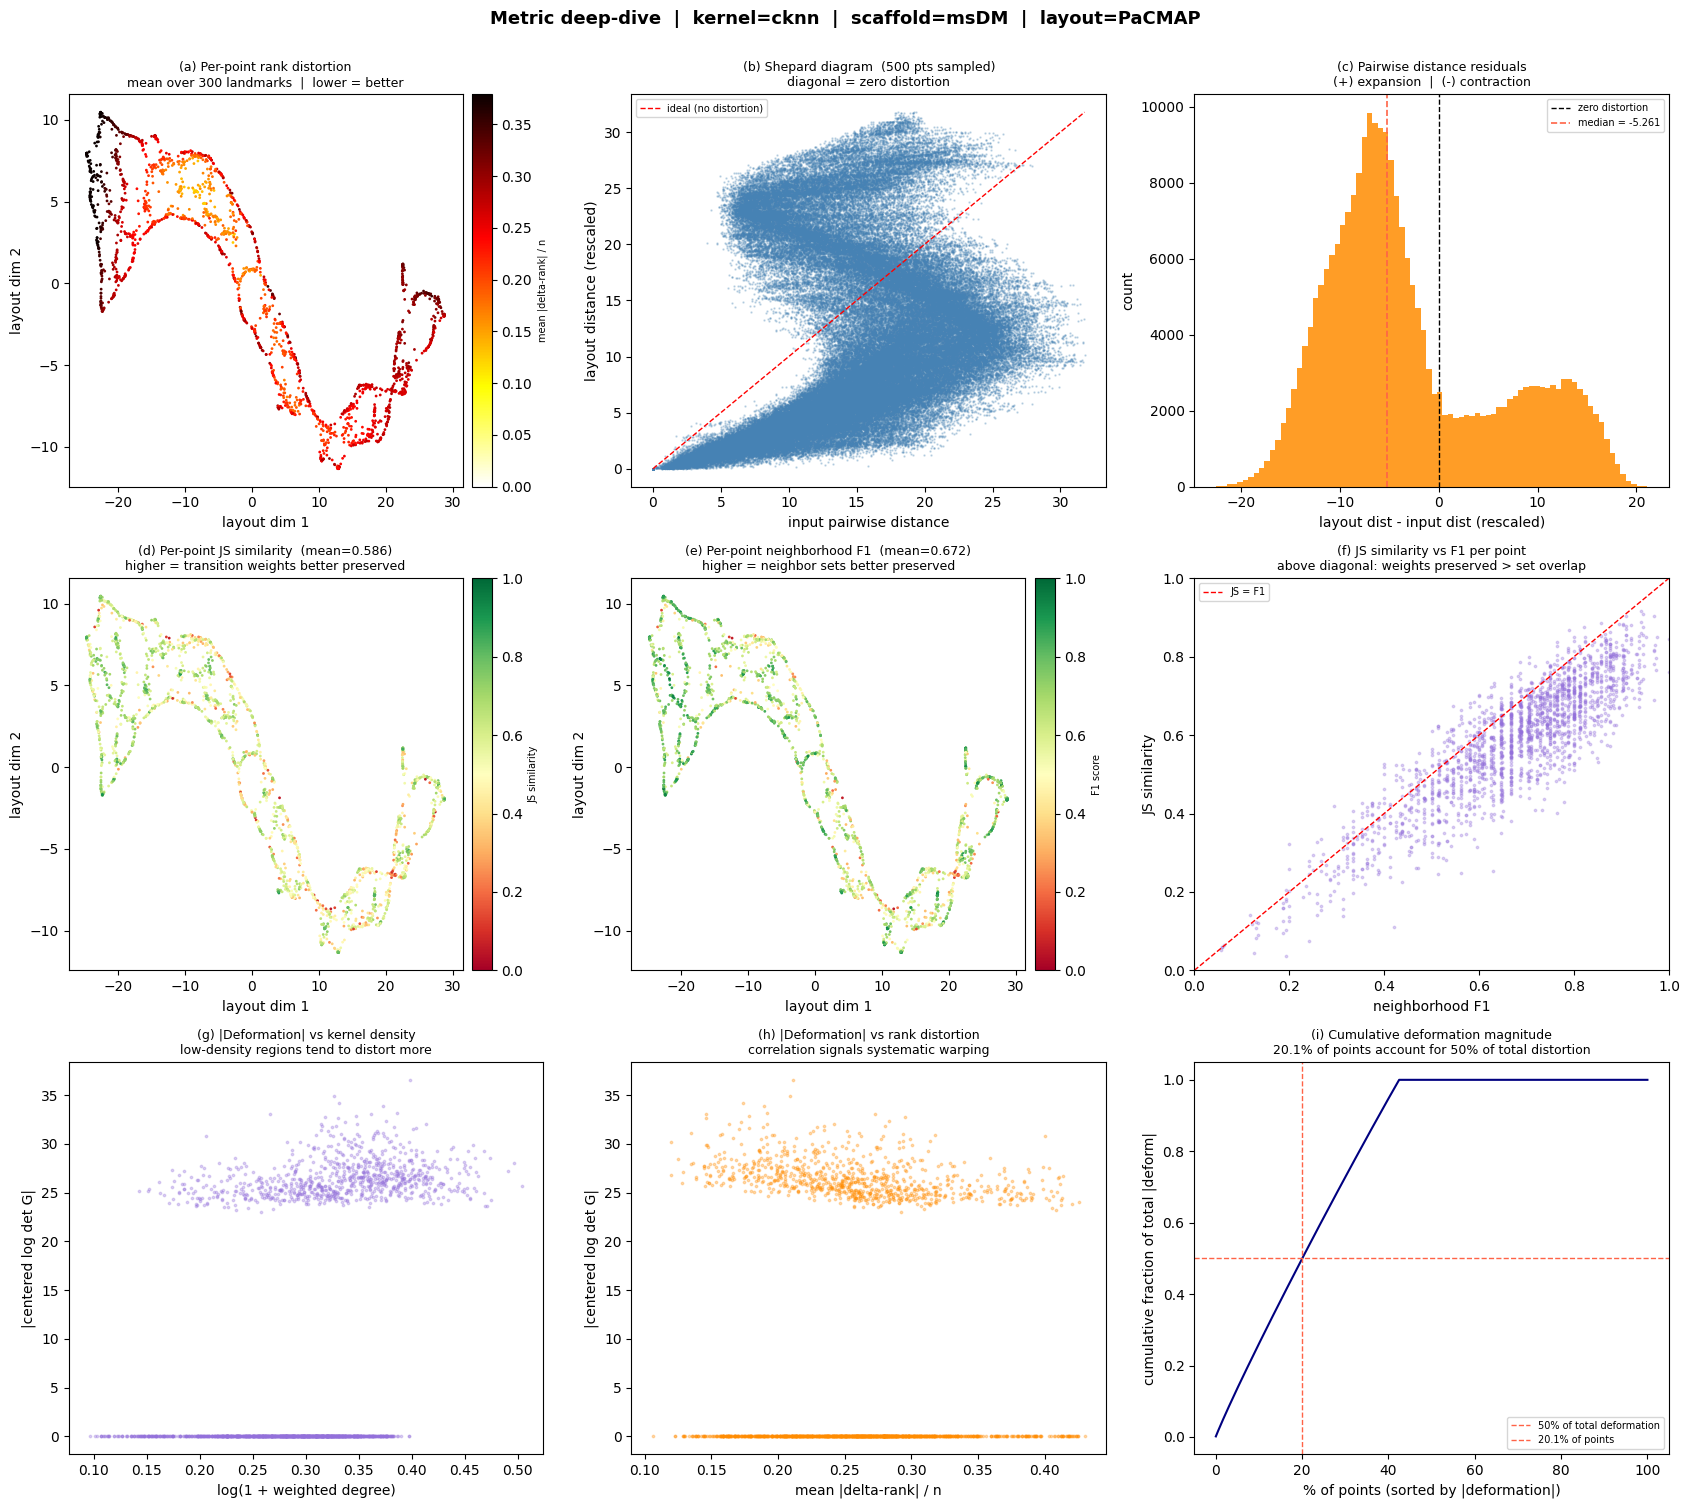

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Metric deep-dive — per-point spatial maps of distortion & topology
# Requires: Cell 9 (Evaluation) to have been run first.
# Reuses: P_input, P_emb, G, deform, vmin_d, vmax_d from Cell 9.
# ══════════════════════════════════════════════════════════════════════════════

# ── Printed summary table ─────────────────────────────────────────────────────
print(f"""
+======================================================================+
|  Geometry-preservation report                                         |
|  kernel={KERNEL_VERSION:<12s}  scaffold={DM_METHOD:<6s}  layout={PROJECTION_METHOD:<10s}|
+======================================================================+
|  GLOBAL STRUCTURE                                                     |
|    vs PCA baseline       : {gs_pca:>6.4f}   (1.0 = perfect PCA match)   |
|    vs Laplacian baseline : {gs_lap:>6.4f}   (1.0 = perfect graph match) |
+----------------------------------------------------------------------+
|  LOCAL GEOMETRY                                                       |
|    Geodesic correlation  : {geo_r:>6.4f}   (Spearman rho)              |
+----------------------------------------------------------------------+
|  DIFFUSION OPERATOR TOPOLOGY                                          |
|    TopoPreserve composite: {score:>6.4f}   (PF1 + PJS + SP)            |
|    Rank diffusion corr.  : {rdc:>6.4f}   (range [-1, 1])              |
|    Spectral similarity   : {spec_sim:>6.4f}   (eigenspace alignment)   |
+----------------------------------------------------------------------+
|  RIEMANNIAN DEFORMATION  (centered log det G)                         |
|    mean = {np.mean(deform):>+7.4f}   std = {np.std(deform):.4f}                     |
|    range = [{deform.min():.3f}, {deform.max():.3f}]                          |
+======================================================================+
""")

# ── Figure: 3x3 deep-dive ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(17, 15))
fig.suptitle(
    f"Metric deep-dive  |  kernel={KERNEL_VERSION}  |  scaffold={DM_METHOD}  |  layout={PROJECTION_METHOD}",
    fontsize=13, fontweight="bold", y=1.002,
)

rng_g = check_random_state(RANDOM_STATE)

# ═══════════════════════════════════════════════════════════════════════════════
# Row 1: Euclidean distortion diagnostics
# ═══════════════════════════════════════════════════════════════════════════════

# (a) Per-point rank distortion (mean |delta-rank| over landmarks)
n_lm = min(300, X.shape[0])
lm   = rng_g.choice(X.shape[0], n_lm, replace=False)
D_inp = cdist(X[lm], X, metric="euclidean")
D_out = cdist(Y[lm], Y, metric="euclidean")
rank_err = np.mean(
    np.abs(
        np.argsort(np.argsort(D_inp, axis=1), axis=1).astype(float) / X.shape[0]
        - np.argsort(np.argsort(D_out, axis=1), axis=1).astype(float) / X.shape[0]
    ),
    axis=0,
)
ax = axes[0, 0]
sc = ax.scatter(Y[:, 0], Y[:, 1], c=rank_err, cmap="hot_r", s=4, linewidths=0,
                vmin=0, vmax=np.percentile(rank_err, 95))
ax.set_title(f"(a) Per-point rank distortion\nmean over {n_lm} landmarks  |  lower = better", fontsize=9)
ax.set_xlabel("layout dim 1"); ax.set_ylabel("layout dim 2")
plt.colorbar(sc, ax=ax, pad=0.02).set_label("mean |delta-rank| / n", fontsize=7)

# (b) Shepard diagram — input vs layout pairwise distances
n_sh   = min(500, X.shape[0])
sh_idx = rng_g.choice(X.shape[0], n_sh, replace=False)
d_in   = cdist(X[sh_idx], X[sh_idx], metric="euclidean").ravel()
d_out  = cdist(Y[sh_idx], Y[sh_idx], metric="euclidean").ravel()
scale_f    = d_in.max() / (d_out.max() + 1e-12)
d_out_sc   = d_out * scale_f
ax = axes[0, 1]
ax.scatter(d_in, d_out_sc, s=0.5, alpha=0.15, color="steelblue", rasterized=True)
ax.plot([0, d_in.max()], [0, d_in.max()], "r--", lw=1, label="ideal (no distortion)")
ax.set_title(f"(b) Shepard diagram  ({n_sh} pts sampled)\ndiagonal = zero distortion", fontsize=9)
ax.set_xlabel("input pairwise distance"); ax.set_ylabel("layout distance (rescaled)")
ax.legend(fontsize=7)

# (c) Distance distortion histogram
distortion = d_out_sc - d_in
ax = axes[0, 2]
ax.hist(distortion, bins=80, color="darkorange", edgecolor="none", alpha=0.85)
ax.axvline(0, color="k", lw=1, ls="--", label="zero distortion")
ax.axvline(np.median(distortion), color="tomato", lw=1.2, ls="--",
           label=f"median = {np.median(distortion):.3f}")
ax.set_title("(c) Pairwise distance residuals\n(+) expansion  |  (-) contraction", fontsize=9)
ax.set_xlabel("layout dist - input dist (rescaled)"); ax.set_ylabel("count")
ax.legend(fontsize=7)

# ═══════════════════════════════════════════════════════════════════════════════
# Row 2: Diffusion-operator per-point maps
# ═══════════════════════════════════════════════════════════════════════════════

# (d) Row-wise JS similarity mapped onto layout
js_per_row = np.array([
    rowwise_js_similarity(P_input[i:i+1], P_emb[i:i+1])
    for i in range(P_input.shape[0])
])
ax = axes[1, 0]
sc = ax.scatter(Y[:, 0], Y[:, 1], c=js_per_row, cmap="RdYlGn",
                s=4, linewidths=0, vmin=0, vmax=1)
ax.set_title(f"(d) Per-point JS similarity  (mean={js_per_row.mean():.3f})\nhigher = transition weights better preserved", fontsize=9)
ax.set_xlabel("layout dim 1"); ax.set_ylabel("layout dim 2")
plt.colorbar(sc, ax=ax, pad=0.02).set_label("JS similarity", fontsize=7)

# (e) Neighborhood F1 mapped onto layout
pf1_per_row = np.array([
    sparse_neighborhood_f1(P_input[i:i+1], P_emb[i:i+1])
    for i in range(P_input.shape[0])
])
ax = axes[1, 1]
sc = ax.scatter(Y[:, 0], Y[:, 1], c=pf1_per_row, cmap="RdYlGn",
                s=4, linewidths=0, vmin=0, vmax=1)
ax.set_title(f"(e) Per-point neighborhood F1  (mean={pf1_per_row.mean():.3f})\nhigher = neighbor sets better preserved", fontsize=9)
ax.set_xlabel("layout dim 1"); ax.set_ylabel("layout dim 2")
plt.colorbar(sc, ax=ax, pad=0.02).set_label("F1 score", fontsize=7)

# (f) JS similarity vs F1 scatter — weight-sensitive vs set-based
ax = axes[1, 2]
ax.scatter(pf1_per_row, js_per_row, s=3, alpha=0.3, color="mediumpurple", rasterized=True)
ax.plot([0, 1], [0, 1], "r--", lw=1, label="JS = F1")
ax.set_title("(f) JS similarity vs F1 per point\nabove diagonal: weights preserved > set overlap", fontsize=9)
ax.set_xlabel("neighborhood F1"); ax.set_ylabel("JS similarity")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=7)

# ═══════════════════════════════════════════════════════════════════════════════
# Row 3: Riemannian deformation
# ═══════════════════════════════════════════════════════════════════════════════

# (g) |deformation| vs local kernel density
log_deg = np.log1p(np.asarray(kernel_Z.K.sum(axis=1)).ravel())
ax = axes[2, 0]
ax.scatter(log_deg, np.abs(deform), s=3, alpha=0.3, color="mediumpurple", rasterized=True)
ax.set_title("(g) |Deformation| vs kernel density\nlow-density regions tend to distort more", fontsize=9)
ax.set_xlabel("log(1 + weighted degree)"); ax.set_ylabel("|centered log det G|")

# (h) |deformation| vs rank distortion — do geometric distortions co-locate?
ax = axes[2, 1]
ax.scatter(rank_err, np.abs(deform), s=3, alpha=0.3, color="darkorange", rasterized=True)
ax.set_title("(h) |Deformation| vs rank distortion\ncorrelation signals systematic warping", fontsize=9)
ax.set_xlabel("mean |delta-rank| / n"); ax.set_ylabel("|centered log det G|")

# (i) Cumulative deformation magnitude
sorted_d = np.sort(np.abs(deform))[::-1]
cumsum_d = np.cumsum(sorted_d) / sorted_d.sum()
pct_pts  = np.linspace(0, 100, len(sorted_d))
ax = axes[2, 2]
ax.plot(pct_pts, cumsum_d, color="navy", lw=1.5)
ax.axhline(0.5, color="tomato", lw=1, ls="--", label="50% of total deformation")
p50 = pct_pts[np.searchsorted(cumsum_d, 0.5)]
ax.axvline(p50, color="tomato", lw=1, ls="--", label=f"{p50:.1f}% of points")
ax.set_title(f"(i) Cumulative deformation magnitude\n{p50:.1f}% of points account for 50% of total distortion", fontsize=9)
ax.set_xlabel("% of points (sorted by |deformation|)")
ax.set_ylabel("cumulative fraction of total |deform|")
ax.legend(fontsize=7)

plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"deepdive_{KERNEL_VERSION}_{DM_METHOD}_{PROJECTION_METHOD}.png",
                dpi=150, bbox_inches="tight")
    print(f"Saved → {OUTPUT_DIR}/deepdive_{KERNEL_VERSION}_{DM_METHOD}_{PROJECTION_METHOD}.png")
plt.show()

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Quick reference — evaluation metrics and interpretation guide
# ══════════════════════════════════════════════════════════════════════════════
print("""
┌──────────────────────────────────────────────────────────────────────────┐
│  EVALUATION METRICS REFERENCE                                            │
│  All scores: higher = better unless noted otherwise.                     │
╠══════════════════════════════════════════════════════════════════════════╣
│                                                                          │
│  ── GLOBAL STRUCTURE ─────────────────────────────────────────────────── │
│  global_score_pca(X, Y)           Range [0, 1]                           │
│    Reconstruction error of the embedding vs PCA baseline.                │
│    1.0 = as good as PCA at preserving variance. Low values are           │
│    expected for nonlinear methods (they sacrifice global for local).     │
│                                                                          │
│  global_score_laplacian(X, Y)     Range [0, 1]                           │
│    Same idea but the baseline is Laplacian Eigenmaps.                    │
│    More relevant than PCA for graph-aware embeddings.                    │
│                                                                          │
│  ── LOCAL GEOMETRY ───────────────────────────────────────────────────── │
│  geodesic_correlation(X, Y)       Range [-1, 1]                          │
│    Spearman rank correlation between shortest-path distances in the      │
│    input kNN graph and Euclidean distances in the layout.                │
│    > 0.8 = excellent local fidelity;  < 0.5 = significant distortion.    │
│                                                                          │
│  ── DIFFUSION-OPERATOR TOPOLOGY (compare transition matrices) ────────   │
│  topo_preserve_score(Px, Py)      Range [0, 1]  (composite)              │
│    Weighted average of three components:                                 │
│      PF1  -- Neighborhood F1: set overlap of top-k neighbors.            │
│      PJS  -- Jensen-Shannon similarity: weight-sensitive row comparison. │
│      SP   -- Spectral Procrustes R^2: alignment of diffusion coords.     │
│    Good embedding: > 0.5.  Perfect: 1.0.                                 │
│                                                                          │
│  rank_diffusion_correlation       Range [-1, 1]                          │
│    Spearman correlation of pairwise diffusion distances across           │
│    multiple timescales.  Captures global geometry agreement.             │
│                                                                          │
│  spectral_similarity              Range [0, 1]                           │
│    Eigenvalue + eigenspace alignment between the two operators.          │
│    1.0 = identical spectral structure.                                   │
│                                                                          │
│  ── RIEMANNIAN DEFORMATION ───────────────────────────────────────────   │
│  RiemannMetric(Y, L)                                                     │
│    Estimates a per-point 2x2 metric tensor G from the embedding Y and    │
│    graph Laplacian L.  From G you can derive:                            │
│      - Metric ellipses: shape = local anisotropy (circles = isotropic)  │
│      - log det(G): local area distortion (contraction < 0 < expansion)  │
│      - Eccentricity: (a-b)/a of the ellipse axes (0 = isotropic)        │
│                                                                         │
│  calculate_deformation(Y, L)      Range (-inf, +inf), centered at 0     │
│    Centered log det(G) per point.  Negative = contraction,              │
│    positive = expansion.  A narrow distribution around 0 means          │
│    the embedding preserves local areas uniformly.                        │
│                                                                          │
│  ── EUCLIDEAN DISTORTION (Shepard-style) ─────────────────────────────   │
│  Per-point rank distortion                                               │
│    Mean |rank_input - rank_layout| / n over landmark subsets.            │
│    0 = perfect rank preservation.  Values > 0.1 indicate trouble.        │
│                                                                          │
│  Shepard diagram                                                         │
│    Scatter of input vs layout pairwise distances.  Points on the         │
│    diagonal = zero distortion.  Spread above/below = expansion/          │
│    contraction.                                                          │
├──────────────────────────────────────────────────────────────────────────┤
│                                                                          │
└──────────────────────────────────────────────────────────────────────────┘
""")


┌──────────────────────────────────────────────────────────────────────────┐
│  EVALUATION METRICS REFERENCE                                            │
│  All scores: higher = better unless noted otherwise.                     │
╠══════════════════════════════════════════════════════════════════════════╣
│                                                                          │
│  ── GLOBAL STRUCTURE ─────────────────────────────────────────────────── │
│  global_score_pca(X, Y)           Range [0, 1]                           │
│    Reconstruction error of the embedding vs PCA baseline.                │
│    1.0 = as good as PCA at preserving variance. Low values are           │
│    expected for nonlinear methods (they sacrifice global for local).     │
│                                                                          │
│  global_score_laplacian(X, Y)     Range [0, 1]                           │
│    Same idea but the baseline is Laplacian Eigenmaps.                    